In [2]:
# Montar Google Drive y cargar el CSV (encoding='utf-8' + arreglo del texto "atrás")
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Sistemas inteligentes/Joystick/ensayos_imu.csv', encoding='utf-8')

# Arreglar manualmente el texto corrupto de "atrás"
df['Direccion'] = df['Direccion'].replace('atr\ufffds', 'atrás')

print(df['Direccion'].unique())
df.head()

Mounted at /content/drive
['adelante' 'atrás' 'derecha' 'izquierda' 'N']


,user_id,trial_id,sample_id,a_x,a_y,a_z,w_x,w_y,w_z,m_x,m_y,m_z,Direccion,velocidad_objetivo
0,0,1,1,-9.52284,-0.57846,-0.53839,4.34000,-1.75875,-4.44500,-104.4,2.4,-204.45,adelante,1.0
1,0,1,2,-9.48455,-0.62154,-0.46481,2.77375,-1.69750,-3.31625,-104.4,2.4,-204.45,adelante,1.0
2,0,1,3,-9.41755,-0.57188,-0.48754,2.57250,-2.94875,-3.76250,-104.4,2.4,-204.45,adelante,1.0
3,0,1,4,-9.45584,-0.60000,-0.47617,3.78000,-3.55250,-4.09500,-104.4,2.4,-204.45,adelante,1.0
4,0,1,5,-9.41636,-0.68315,-0.54257,3.63125,-4.46250,-3.57875,-104.4,2.4,-204.45,adelante,1.0


In [3]:
# Filtrar solo adelante, atrás y neutral (N) - los movimientos relacionados con roll/velocidad
df_roll = df[df['Direccion'].isin(['adelante', 'atrás', 'N'])].copy()

print("Tamaño después de filtrar:", df_roll.shape)
print(df_roll['Direccion'].value_counts())

Tamaño después de filtrar: (6242, 14)
Direccion
adelante    2878
atrás       2562
N            802
Name: count, dtype: int64


In [6]:
# Calcular el ángulo de inclinación (roll) a partir del acelerómetro, y su valor absoluto
import numpy as np

df_roll['angulo_roll'] = np.degrees(np.arctan2(df_roll['a_z'], -df_roll['a_x']))
df_roll['angulo_abs'] = df_roll['angulo_roll'].abs()
df_roll[['a_x', 'a_z', 'angulo_roll', 'angulo_abs', 'Direccion', 'velocidad_objetivo']].head(10)

,a_x,a_z,angulo_roll,angulo_abs,Direccion,velocidad_objetivo
0,-9.52284,-0.53839,-3.235870,3.235870,adelante,1.0
1,-9.48455,-0.46481,-2.805654,2.805654,adelante,1.0
2,-9.41755,-0.48754,-2.963517,2.963517,adelante,1.0
3,-9.45584,-0.47617,-2.882822,2.882822,adelante,1.0
4,-9.41636,-0.54257,-3.297732,3.297732,adelante,1.0
5,-9.50130,-0.54138,-3.261163,3.261163,adelante,1.0
6,-9.52164,-0.52582,-3.160873,3.160873,adelante,1.0
7,-9.58325,-0.55394,-3.308183,3.308183,adelante,1.0
8,-9.50788,-0.59821,-3.600149,3.600149,adelante,1.0
9,-9.70708,-0.60658,-3.575673,3.575673,adelante,1.0


In [7]:
# Quedarnos solo con el "pico" de cada trial (85% del ángulo máximo alcanzado en ese trial)
max_por_trial = df_roll.groupby('trial_id')['angulo_abs'].transform('max')
df_pico = df_roll[df_roll['angulo_abs'] >= 0.85 * max_por_trial].copy()
print("Filas originales (df_roll):", len(df_roll))
print("Filas después de quedarnos con el pico (df_pico):", len(df_pico))

Filas originales (df_roll): 6242
Filas después de quedarnos con el pico (df_pico): 1135


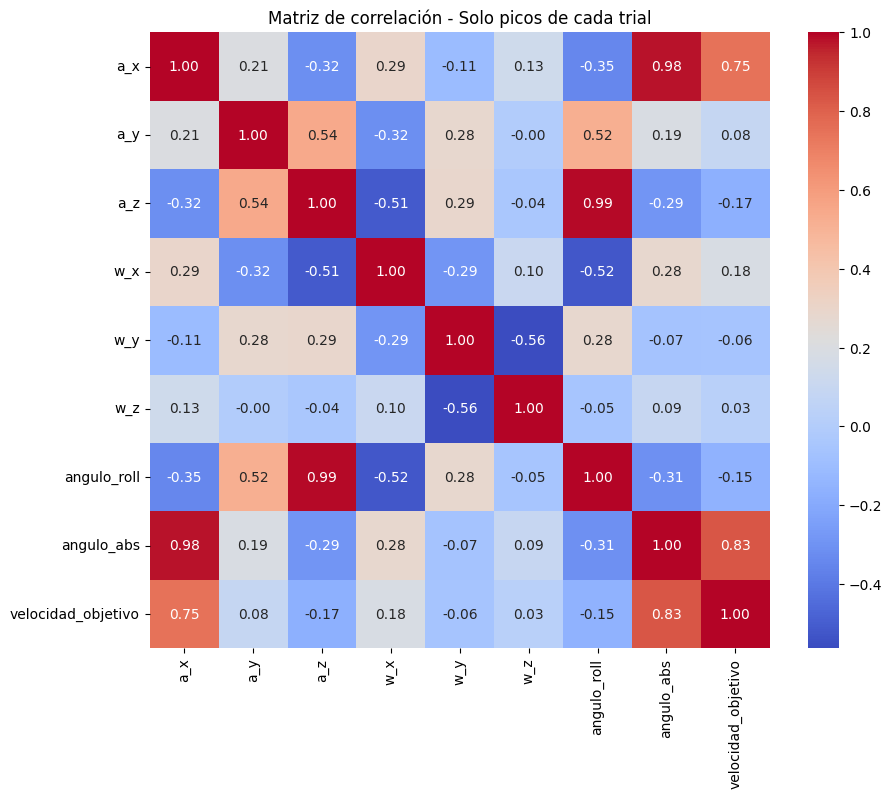

In [8]:
# Matriz de correlación (para justificar la selección de características)
import matplotlib.pyplot as plt
import seaborn as sns
columnas_analisis = ['a_x', 'a_y', 'a_z', 'w_x', 'w_y', 'w_z', 'angulo_roll', 'angulo_abs', 'velocidad_objetivo']
correlacion_pico = df_pico[columnas_analisis].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacion_pico, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación - Solo picos de cada trial')
plt.show()

In [10]:
# Seleccionar características (angulo_abs, w_x, w_y) y dividir train/test (80/20)
from sklearn.model_selection import train_test_split

X = df_pico[['angulo_abs', 'w_x', 'w_y']]
y = df_pico['velocidad_objetivo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)

Tamaño X_train: (908, 3)
Tamaño X_test: (227, 3)


In [11]:
# Escalar las 3 características (fit solo en train, transform en train y test)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled[:5])

[[ 0.77489468 -0.18517     0.0808881 ]
 [ 0.44335043 -0.14102523 -1.71354509]
 [-1.145542   -0.25363944 -0.1046074 ]
 [-0.15606168 -0.51670622  2.20052792]
 [-1.09453647 -0.05498798  0.01289928]]


In [14]:
# Modelo LINEAL con Gradiente Descendente
from sklearn.metrics import mean_absolute_error, r2_score

X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

alpha = 0.1
n_iteraciones = 1000
m_train = X_train_b.shape[0]
m_test = X_test_b.shape[0]
theta = np.zeros(X_train_b.shape[1])
historial_costo_train = []
historial_costo_test = []

for i in range(n_iteraciones):
  predicciones_train = X_train_b.dot(theta)
  error_train = predicciones_train - y_train.values
  gradiente = (1/m_train) * X_train_b.T.dot(error_train)
  theta = theta - alpha * gradiente
  costo_train = (1/(2*m_train)) * np.sum((X_train_b.dot(theta) - y_train.values)**2)
  historial_costo_train.append(costo_train)
  costo_test = (1/(2*m_test)) * np.sum((X_test_b.dot(theta) - y_test.values)**2)
  historial_costo_test.append(costo_test)

y_train_pred = X_train_b.dot(theta)
y_test_pred = X_test_b.dot(theta)

print("Theta encontrado (lineal):", theta)
print("---- TRAIN (Lineal) ----")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R²:", r2_score(y_train, y_train_pred))
print("---- TEST (Lineal) ----")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R²:", r2_score(y_test, y_test_pred))

Theta encontrado (lineal): [ 0.66657489  0.35958361 -0.03021017 -0.0068617 ]
---- TRAIN (Lineal) ----
MAE: 0.1840183221172586
R²: 0.6995047743501893
---- TEST (Lineal) ----
MAE: 0.16923920198266693
R²: 0.6866488177964922


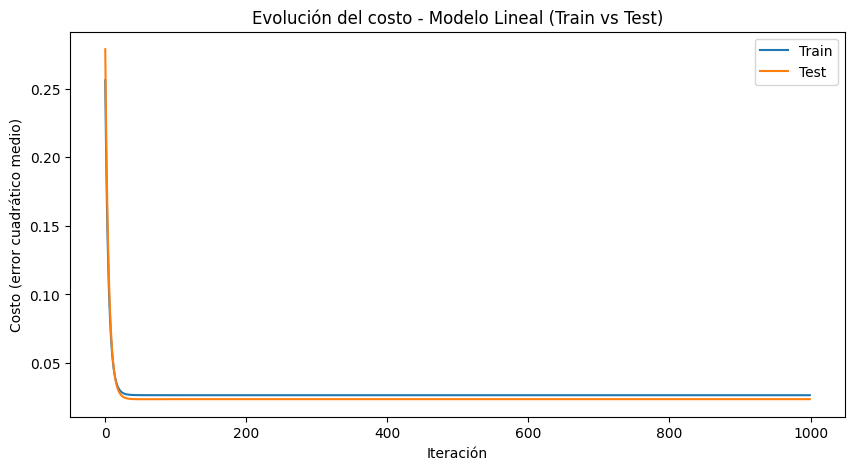

In [15]:
# Gráfica de evolución del costo - Modelo Lineal (train vs test)
plt.figure(figsize=(10, 5))
plt.plot(range(n_iteraciones), historial_costo_train, label='Train')
plt.plot(range(n_iteraciones), historial_costo_test, label='Test')
plt.xlabel('Iteración')
plt.ylabel('Costo (error cuadrático medio)')
plt.title('Evolución del costo - Modelo Lineal (Train vs Test)')
plt.legend()
plt.show()

In [16]:
# Generar características polinómicas de grado 2 y escalarlas
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("Características generadas:", poly.get_feature_names_out())
scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)
X_train_poly_b = np.c_[np.ones((X_train_poly_scaled.shape[0], 1)), X_train_poly_scaled]
X_test_poly_b = np.c_[np.ones((X_test_poly_scaled.shape[0], 1)), X_test_poly_scaled]

Características generadas: ['angulo_abs' 'w_x' 'w_y' 'angulo_abs^2' 'angulo_abs w_x' 'angulo_abs w_y'
 'w_x^2' 'w_x w_y' 'w_y^2']


In [17]:
# Modelo POLINÓMICO con Gradiente Descendente

theta_poly = np.zeros(X_train_poly_b.shape[1])
m_train = X_train_poly_b.shape[0]
m_test = X_test_poly_b.shape[0]

historial_costo_train_poly = []
historial_costo_test_poly = []

for i in range(n_iteraciones):
  predicciones_train = X_train_poly_b.dot(theta_poly)
  error_train = predicciones_train - y_train.values
  gradiente = (1/m_train) * X_train_poly_b.T.dot(error_train)
  theta_poly = theta_poly - alpha * gradiente

  costo_train = (1/(2*m_train)) * np.sum((X_train_poly_b.dot(theta_poly) - y_train.values)**2)
  historial_costo_train_poly.append(costo_train)

  costo_test = (1/(2*m_test)) * np.sum((X_test_poly_b.dot(theta_poly) - y_test.values)**2)
  historial_costo_test_poly.append(costo_test)

y_train_pred_poly = X_train_poly_b.dot(theta_poly)
y_test_pred_poly = X_test_poly_b.dot(theta_poly)
print("Theta polinómico:", theta_poly)
print("---- TRAIN (Polinómico) ----")
print("MAE:", mean_absolute_error(y_train, y_train_pred_poly))
print("R²:", r2_score(y_train, y_train_pred_poly))
print("---- TEST (Polinómico) ----")
print("MAE:", mean_absolute_error(y_test, y_test_pred_poly))
print("R²:", r2_score(y_test, y_test_pred_poly))

Theta polinómico: [ 0.66657489  0.80386927 -0.01309359 -0.14718238 -0.46418315  0.01453122
  0.11901392  0.00294823  0.02212228  0.0322368 ]
---- TRAIN (Polinómico) ----
MAE: 0.1236530435557085
R²: 0.834007583493533
---- TEST (Polinómico) ----
MAE: 0.10878007785216649
R²: 0.8456189755292519


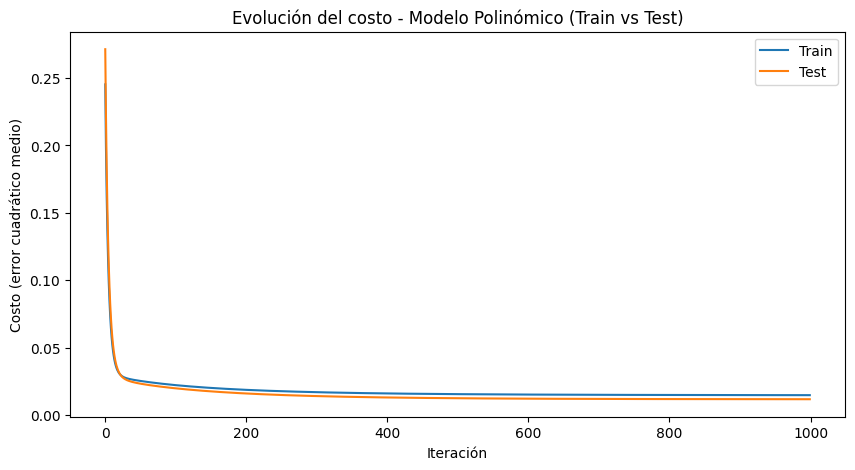

In [20]:
# Gráfica de evolución del costo - Modelo Polinómico (train vs test)
plt.figure(figsize=(10, 5))
plt.plot(range(n_iteraciones), historial_costo_train_poly, label='Train')
plt.plot(range(n_iteraciones), historial_costo_test_poly, label='Test')
plt.xlabel('Iteración')
plt.ylabel('Costo (error cuadrático medio)')
plt.title('Evolución del costo - Modelo Polinómico (Train vs Test)')
plt.legend()
plt.show()

In [21]:
# Comparación final -> se selecciona el modelo Polinómico (mejor R² y MAE en test)
print("=== COMPARACIÓN FINAL ===")
print(f"Lineal      -> MAE test: {mean_absolute_error(y_test, y_test_pred):.4f} | R² test: {r2_score(y_test, y_test_pred):.4f}")
print(f"Polinómico  -> MAE test: {mean_absolute_error(y_test, y_test_pred_poly):.4f} | R² test: {r2_score(y_test, y_test_pred_poly):.4f}")

=== COMPARACIÓN FINAL ===
Lineal      -> MAE test: 0.1692 | R² test: 0.6866
Polinómico  -> MAE test: 0.1088 | R² test: 0.8456


In [22]:
# Parámetros finales para programar el microcontrolador (theta + escaladores)
print("=== Scaler original (angulo_abs, w_x, w_y) ===")
print("Promedios:", scaler.mean_)
print("Desviaciones:", scaler.scale_)
print()
print("=== Scaler polinómico (9 features) ===")
print("Orden:", poly.get_feature_names_out())
print("Promedios:", scaler_poly.mean_)
print("Desviaciones:", scaler_poly.scale_)
print()
print("=== Theta final (modelo Polinómico) ===")
print(theta_poly)

=== Scaler original (angulo_abs, w_x, w_y) ===
Promedios: [38.10096507  7.73562638 -1.76439703]
Desviaciones: [25.89619806 19.42472526 44.5293814 ]

=== Scaler polinómico (9 features) ===
Orden: ['angulo_abs' 'w_x' 'w_y' 'angulo_abs^2' 'angulo_abs w_x' 'angulo_abs w_y'
 'w_x^2' 'w_x w_y' 'w_y^2']
Promedios: [ 3.81009651e+01  7.73562638e+00 -1.76439703e+00  2.12229661e+03
  4.48215522e+02 -1.43665112e+02  4.37159867e+02 -2.74597072e+02
  1.98597891e+03]
Desviaciones: [  25.89619806   19.42472526   44.5293814  2189.85809529 1286.45872902
 2274.87676336 1313.35371098 1229.23159976 3294.56183187]

=== Theta final (modelo Polinómico) ===
[ 0.66657489  0.80386927 -0.01309359 -0.14718238 -0.46418315  0.01453122
  0.11901392  0.00294823  0.02212228  0.0322368 ]
